# ExploRFM Inference Demo

Run [ExploRFM](explorfm_model.py) on RGB frames from the ASL `highrange_rgb_nav_graph` missions and visualize the three outputs. Includes an interactive mission dropdown + frame slider for quick scrubbing.

## What the network does

ExploRFM is the vision module of WildOS. It is a single-encoder / multi-head model:

**Backbone — language-aligned RADIO (NVIDIA C-RADIOv3-B).** A ViT-style image encoder (`radio_dim=768`) distilled from multiple foundation models. This repo modifies it in two ways: (1) **NACLIP** rewires self-attention with a Gaussian neighborhood prior (`naclip_strategy="kkonly"`, `gaussian_std=5.0`) so dense patch features are spatially coherent enough for open-vocab segmentation; (2) a **SigLIP2** adaptor produces a parallel set of patch features in the SigLIP2 vision-language embedding space, dottable with text-tower outputs.

**Forward pass** ([ExploRFM.forward](explorfm_model.py#L143)):
1. Resize input to a multiple of `radio.min_resolution_step`, scaled by `static_scale_factor` (0.5 here).
2. Run RADIO once → `spatial_features` at ~1/16 resolution.
3. Same call returns `ad_spatial_features` (1152-D SigLIP2-aligned) for OV similarity.

**Two CNN heads** decode `spatial_features`. Identical 4× (`ConvTranspose2d` stride-2 → `Conv2d` 3×3 → `ReLU`) stacks halving channels (768→384→192→96→1) and upsampling 16×, then bilinear resize + sigmoid:
- **Traversability head** — per-pixel safe-to-drive probability.
- **Frontier head** — per-pixel probability of being a *visual frontier* (exploration-worthy direction past the depth horizon).

**Open-vocabulary similarity.** L2-normalize the SigLIP2 patch features and dot them with text embeddings from the SigLIP2 text tower → per-patch heatmap upsampled to image resolution.

## Prerequisites

```bash
uv pip install -r explorfm/requirements.txt
uv pip install -e ./nvidia_radio ./explorfm
```

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path('/home/rohang73/Desktop/rgn_graph_cleaning/nebula2-wildos')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output

from explorfm.explorfm_model import ExploRFMInference

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


In [2]:
CKPTS = REPO_ROOT / 'ckpts'
FRONTIER_CKPT = str(CKPTS / 'frontier_head.ckpt')
TRAV_CKPT     = str(CKPTS / 'trav_head.ckpt')
SIGLIP2_DIR   = str(CKPTS / 'siglip2')

_local_radio = CKPTS / 'c-radio_v3-b_half.pth.tar'
RADIO_VERSION = str(_local_radio) if _local_radio.exists() else 'c-radio_v3-b'
print('radio backbone:', RADIO_VERSION)

model = ExploRFMInference(
    frontier_ckpt=FRONTIER_CKPT,
    traversability_ckpt=TRAV_CKPT,
    model_version=RADIO_VERSION,
    adaptor_version='siglip2',
    adaptor_ckpt_path=SIGLIP2_DIR,
    use_naclip=True,
    use_summary_for_spatial=True,
    radio_dim=768,
    static_scale_factor=0.5,
    model_precision='FP32',
    device=DEVICE,
)

radio backbone: c-radio_v3-b
[INFO] Loading SigLIP2 model and processor for version: google/siglip2-so400m-patch16-naflex
[INFO] Using checkpoint path: /home/rohang73/Desktop/rgn_graph_cleaning/nebula2-wildos/ckpts/siglip2
Loaded traversability head from /home/rohang73/Desktop/rgn_graph_cleaning/nebula2-wildos/ckpts/trav_head.ckpt
Loaded frontier head from /home/rohang73/Desktop/rgn_graph_cleaning/nebula2-wildos/ckpts/frontier_head.ckpt


## Interactive viewer

Pick a mission and scrub the frame slider. Inference runs on slider release (`continuous_update=False`) so you can drag freely. The most recently rendered frame's `img_np` and `ad_feats` are kept in globals so the text-similarity cell below can reuse them.

In [3]:
DATASET_ROOT = Path('/home/rohang73/Desktop/longrange')
DEFAULT_MISSION = 'highrange_rgb_nav_graph_dataset_2024-11-11-12-42-47_mission'

def list_missions():
    return sorted(p.name for p in DATASET_ROOT.iterdir() if p.is_dir())

def list_frames(mission):
    return sorted(p.name for p in (DATASET_ROOT / mission).glob('rgb_*.png'))

def overlay(rgb_uint8, mask01, cmap='magma', alpha=0.55):
    cm = plt.get_cmap(cmap)
    heat = (cm(mask01)[..., :3] * 255).astype(np.uint8)
    return ((1 - alpha) * rgb_uint8 + alpha * heat).astype(np.uint8)

missions = list_missions()
init_mission = DEFAULT_MISSION if DEFAULT_MISSION in missions else missions[0]
print(f'{len(missions)} missions found, default: {init_mission}')

16 missions found, default: highrange_rgb_nav_graph_dataset_2024-11-11-12-42-47_mission


In [4]:
img_np = None
trav_np = None
front_np = None
ad_feats = None
current_frames = []

mission_dd = widgets.Dropdown(options=missions, value=init_mission,
                              description='Mission:',
                              layout=widgets.Layout(width='90%'),
                              style={'description_width': '90px'})
frame_sl = widgets.IntSlider(min=0, max=0, step=1, value=0,
                             description='Frame idx:',
                             continuous_update=False,
                             layout=widgets.Layout(width='90%'),
                             style={'description_width': '90px'})
label = widgets.Label(value='')
out = widgets.Output()

def render():
    global img_np, trav_np, front_np, ad_feats
    if not current_frames:
        return
    fname = current_frames[frame_sl.value]
    path = DATASET_ROOT / mission_dd.value / fname
    img_np = np.array(Image.open(path).convert('RGB'))
    with torch.inference_mode():
        trav, front, ad_feats = model.forward_on_numpy(img_np)
    trav_np  = trav.squeeze().float().cpu().numpy()
    front_np = front.squeeze().float().cpu().numpy()
    nontrav_np = 1.0 - trav_np
    label.value = f'{fname}    {img_np.shape[1]}x{img_np.shape[0]}    frame {frame_sl.value+1}/{len(current_frames)}'
    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.ravel()
        axes[0].imshow(img_np);                                  axes[0].set_title('RGB')
        axes[1].imshow(overlay(img_np, trav_np,    'viridis'));  axes[1].set_title('Traversability (bright = safe)')
        axes[2].imshow(overlay(img_np, nontrav_np, 'inferno'));  axes[2].set_title('Non-traversability (bright = unsafe)')
        axes[3].imshow(overlay(img_np, front_np,   'magma'));    axes[3].set_title('Frontiers (bright = explore)')
        for a in axes: a.axis('off')
        plt.tight_layout(); plt.show()

def on_mission_change(change):
    global current_frames
    current_frames = list_frames(change['new'])
    frame_sl.unobserve(on_frame_change, names='value')
    frame_sl.max = max(0, len(current_frames) - 1)
    frame_sl.value = 0
    frame_sl.observe(on_frame_change, names='value')
    render()

def on_frame_change(change):
    render()

current_frames = list_frames(init_mission)
frame_sl.max = max(0, len(current_frames) - 1)
default_frame = 'rgb_000650.png'
if default_frame in current_frames:
    frame_sl.value = current_frames.index(default_frame)

mission_dd.observe(on_mission_change, names='value')
frame_sl.observe(on_frame_change, names='value')

display(widgets.VBox([mission_dd, frame_sl, label, out]))
render()

## Graph overlay

For each frame, the dataset ships a `graph_NNNNNN.json` with nav-graph nodes (their pixel coords and `type` — `free_space` or `frontier`). Each node is bucketed by sampling the predicted traversability at its pixel: nodes with `trav >= GRAPH_TRAV_THRESHOLD` go on the traversable panel, the rest on the non-traversable panel. Lets you eyeball whether the head agrees with where the planner actually placed nodes.

In [22]:
import json

GRAPH_TRAV_THRESHOLD = 0.5  # nodes with trav < this go on the non-traversable panel

def load_graph_for_frame(mission, rgb_fname):
    idx = rgb_fname.replace('rgb_', '').replace('.png', '')
    gpath = DATASET_ROOT / mission / f'graph_{idx}.json'
    if not gpath.exists():
        return None
    with open(gpath) as f:
        return json.load(f)

graph_img_np = None
graph_trav_np = None
graph_current_frames = []

graph_mission_dd = widgets.Dropdown(options=missions, value=init_mission,
                                    description='Mission:',
                                    layout=widgets.Layout(width='90%'),
                                    style={'description_width': '90px'})
graph_frame_sl = widgets.IntSlider(min=0, max=0, step=1, value=0,
                                   description='Frame idx:',
                                   continuous_update=False,
                                   layout=widgets.Layout(width='90%'),
                                   style={'description_width': '90px'})
graph_label = widgets.Label(value='')
graph_out = widgets.Output()

def graph_render():
    global graph_img_np, graph_trav_np
    if not graph_current_frames:
        return
    fname = graph_current_frames[graph_frame_sl.value]
    mission = graph_mission_dd.value
    path = DATASET_ROOT / mission / fname
    graph_img_np = np.array(Image.open(path).convert('RGB'))
    with torch.inference_mode():
        trav, _, _ = model.forward_on_numpy(graph_img_np)
    graph_trav_np = trav.squeeze().float().cpu().numpy()
    H, W = graph_img_np.shape[:2]

    graph_data = load_graph_for_frame(mission, fname)
    trav_pts, nontrav_pts = [], []
    if graph_data is not None:
        for n in graph_data.get('nodes', []):
            x, y = int(round(n['pixel'][0])), int(round(n['pixel'][1]))
            if 0 <= x < W and 0 <= y < H:
                v = graph_trav_np[y, x]
                bucket = trav_pts if v >= GRAPH_TRAV_THRESHOLD else nontrav_pts
                bucket.append((x, y, n.get('type', '')))

    info = (f'{len(trav_pts)} trav / {len(nontrav_pts)} non-trav nodes'
            if graph_data is not None else 'no graph json')
    graph_label.value = (f'{fname}    {W}x{H}    '
                         f'frame {graph_frame_sl.value+1}/{len(graph_current_frames)}    {info}')

    def scatter(ax, pts, color):
        if not pts:
            return
        xs, ys, types = zip(*pts)
        is_frontier = np.array([t == 'frontier' for t in types])
        xs, ys = np.array(xs), np.array(ys)
        if (~is_frontier).any():
            ax.scatter(xs[~is_frontier], ys[~is_frontier],
                       s=28, c=color, edgecolors='black', linewidths=0.6, marker='o')
        if is_frontier.any():
            ax.scatter(xs[is_frontier], ys[is_frontier],
                       s=44, c=color, edgecolors='black', linewidths=0.7, marker='*')

    with graph_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(graph_img_np); axes[0].set_title('RGB')
        axes[1].imshow(graph_img_np)
        scatter(axes[1], trav_pts, 'lime')
        axes[1].set_title(f'Traversable nodes ({len(trav_pts)})')
        axes[2].imshow(graph_img_np)
        scatter(axes[2], nontrav_pts, 'red')
        axes[2].set_title(f'Non-traversable nodes ({len(nontrav_pts)})')
        for a in axes: a.axis('off')
        plt.tight_layout(); plt.show()

def graph_on_mission_change(change):
    global graph_current_frames
    graph_current_frames = list_frames(change['new'])
    graph_frame_sl.unobserve(graph_on_frame_change, names='value')
    graph_frame_sl.max = max(0, len(graph_current_frames) - 1)
    graph_frame_sl.value = 0
    graph_frame_sl.observe(graph_on_frame_change, names='value')
    graph_render()

def graph_on_frame_change(change):
    graph_render()

graph_current_frames = list_frames(init_mission)
graph_frame_sl.max = max(0, len(graph_current_frames) - 1)
default_frame = 'rgb_000650.png'
if default_frame in graph_current_frames:
    graph_frame_sl.value = graph_current_frames.index(default_frame)

graph_mission_dd.observe(graph_on_mission_change, names='value')
graph_frame_sl.observe(graph_on_frame_change, names='value')

display(widgets.VBox([graph_mission_dd, graph_frame_sl, graph_label, graph_out]))
graph_render()

## Open-vocabulary similarity

Uses the image currently shown in the widget above. Edit `queries` and re-run.

Source frame: rgb_000650.png    1920x1280    frame 14/83


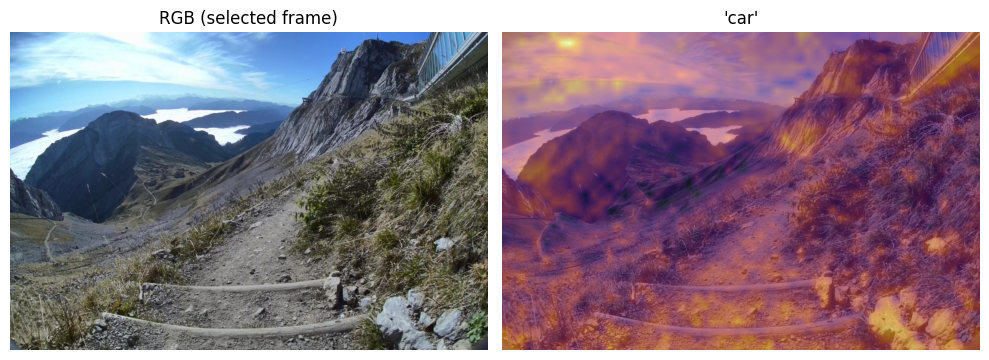

In [10]:
queries = ['car']

assert img_np is not None and ad_feats is not None, \
    'Run the interactive viewer cell first (and pick a frame) so img_np / ad_feats are populated.'
print('Source frame:', label.value)

with torch.inference_mode():
    text_emb = model.forward_on_text(queries)

patch = F.normalize(ad_feats.float(), dim=1)
text  = F.normalize(text_emb.float(),  dim=-1)
sim = torch.einsum('nd,bdhw->bnhw', text, patch)
sim_full = F.interpolate(sim, size=img_np.shape[:2], mode='bilinear', align_corners=False)[0].cpu().numpy()

fig, axes = plt.subplots(1, len(queries) + 1, figsize=(5 * (len(queries) + 1), 5), squeeze=False)
axes = axes[0]
axes[0].imshow(img_np); axes[0].set_title('RGB (selected frame)'); axes[0].axis('off')
for ax, q, s in zip(axes[1:], queries, sim_full):
    s01 = (s - s.min()) / (s.max() - s.min() + 1e-8)
    ax.imshow(overlay(img_np, s01, 'inferno'))
    ax.set_title(f"'{q}'"); ax.axis('off')
plt.tight_layout(); plt.show()
